In [174]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [175]:
df = pd.read_csv("../data/LogisticRegression/HR_comma_sep.csv")
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [176]:
dummies_depart = pd.get_dummies(df.Department)
dummies_salary = pd.get_dummies(df.salary)

In [177]:
merged = pd.concat([df, dummies_depart, dummies_salary], axis=1)
merged

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary,...,hr,management,marketing,product_mng,sales,support,technical,high,low,medium
0,0.38,0.53,2,157,3,0,1,0,sales,low,...,False,False,False,False,True,False,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,sales,medium,...,False,False,False,False,True,False,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,sales,medium,...,False,False,False,False,True,False,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,sales,low,...,False,False,False,False,True,False,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,sales,low,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low,...,False,False,False,False,False,True,False,False,True,False
14995,0.37,0.48,2,160,3,0,1,0,support,low,...,False,False,False,False,False,True,False,False,True,False
14996,0.37,0.53,2,143,3,0,1,0,support,low,...,False,False,False,False,False,True,False,False,True,False
14997,0.11,0.96,6,280,4,0,1,0,support,low,...,False,False,False,False,False,True,False,False,True,False


In [178]:
final = merged.drop(['Department', 'salary'], axis=1)
final

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,IT,RandD,...,hr,management,marketing,product_mng,sales,support,technical,high,low,medium
0,0.38,0.53,2,157,3,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,...,False,False,False,False,True,False,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,False,False,...,False,False,False,False,False,True,False,False,True,False
14995,0.37,0.48,2,160,3,0,1,0,False,False,...,False,False,False,False,False,True,False,False,True,False
14996,0.37,0.53,2,143,3,0,1,0,False,False,...,False,False,False,False,False,True,False,False,True,False
14997,0.11,0.96,6,280,4,0,1,0,False,False,...,False,False,False,False,False,True,False,False,True,False


In [179]:
X = final.drop(['last_evaluation', "Work_accident", "left"], axis='columns')
X

,satisfaction_level,number_project,average_montly_hours,time_spend_company,promotion_last_5years,IT,RandD,accounting,hr,management,marketing,product_mng,sales,support,technical,high,low,medium
0,0.38,2,157,3,0,False,False,False,False,False,False,False,True,False,False,False,True,False
1,0.80,5,262,6,0,False,False,False,False,False,False,False,True,False,False,False,False,True
2,0.11,7,272,4,0,False,False,False,False,False,False,False,True,False,False,False,False,True
3,0.72,5,223,5,0,False,False,False,False,False,False,False,True,False,False,False,True,False
4,0.37,2,159,3,0,False,False,False,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,2,151,3,0,False,False,False,False,False,False,False,False,True,False,False,True,False
14995,0.37,2,160,3,0,False,False,False,False,False,False,False,False,True,False,False,True,False
14996,0.37,2,143,3,0,False,False,False,False,False,False,False,False,True,False,False,True,False
14997,0.11,6,280,4,0,False,False,False,False,False,False,False,False,True,False,False,True,False


In [180]:
Y = final['left']
Y

0        1
1        1
2        1
3        1
4        1
        ..
14994    1
14995    1
14996    1
14997    1
14998    1
Name: left, Length: 14999, dtype: int64

In [181]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.1, random_state=42)

In [182]:
x_train

,satisfaction_level,number_project,average_montly_hours,time_spend_company,promotion_last_5years,IT,RandD,accounting,hr,management,marketing,product_mng,sales,support,technical,high,low,medium
11809,0.93,4,110,3,0,False,False,False,False,False,False,True,False,False,False,False,True,False
970,0.38,2,147,3,0,False,False,False,False,False,False,False,False,True,False,False,True,False
1598,0.83,5,273,5,0,False,True,False,False,False,False,False,False,False,False,False,False,True
11804,0.64,3,252,2,0,False,False,False,False,False,False,False,True,False,False,False,True,False
2582,0.58,5,271,3,0,True,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5191,0.52,4,246,3,0,False,False,False,False,False,False,False,False,True,False,False,True,False
13418,0.49,4,233,7,0,False,False,False,False,False,False,False,True,False,False,False,False,True
5390,0.66,5,249,2,0,False,False,False,False,False,False,False,False,True,False,False,False,True
860,0.79,4,218,5,0,False,False,False,False,False,False,False,True,False,False,False,True,False


In [183]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

In [184]:
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [185]:
model.predict(x_test)

array([0, 0, 0, ..., 0, 1, 0], shape=(1500,))

In [186]:
model.score(x_test, y_test)

0.7626666666666667

Plotting Relation Barcharts

Impact of Employee Salaries on retention:

In [187]:
final

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,IT,RandD,...,hr,management,marketing,product_mng,sales,support,technical,high,low,medium
0,0.38,0.53,2,157,3,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,...,False,False,False,False,True,False,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,False,False,...,False,False,False,False,False,True,False,False,True,False
14995,0.37,0.48,2,160,3,0,1,0,False,False,...,False,False,False,False,False,True,False,False,True,False
14996,0.37,0.53,2,143,3,0,1,0,False,False,...,False,False,False,False,False,True,False,False,True,False
14997,0.11,0.96,6,280,4,0,1,0,False,False,...,False,False,False,False,False,True,False,False,True,False


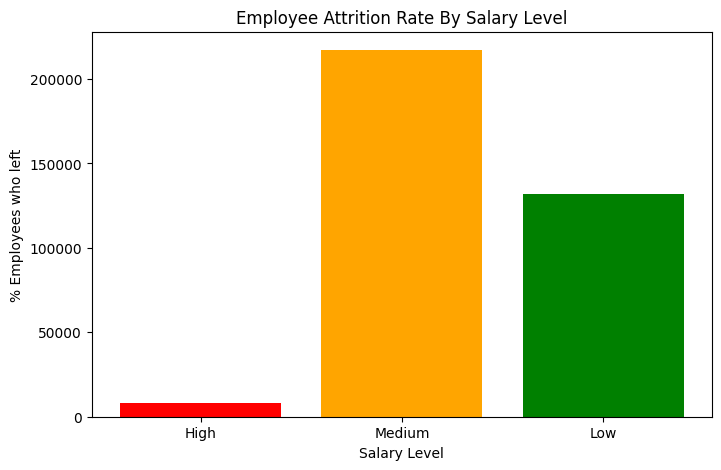

In [188]:
salary_cols = ['high','low', 'medium' ]
attrition_rates = final[salary_cols].apply(lambda col: final[final['left'] == 1][col.name].sum() * 100)
plt.figure(figsize =(8,5))
plt.bar(['High', 'Medium', 'Low'], attrition_rates.values, color=['red', 'orange', 'green'])
plt.title("Employee Attrition Rate By Salary Level")
plt.xlabel("Salary Level")
plt.ylabel("% Employees who left")
plt.show()

In [189]:
final.columns.tolist()

['satisfaction_level',
 'last_evaluation',
 'number_project',
 'average_montly_hours',
 'time_spend_company',
 'Work_accident',
 'left',
 'promotion_last_5years',
 'IT',
 'RandD',
 'accounting',
 'hr',
 'management',
 'marketing',
 'product_mng',
 'sales',
 'support',
 'technical',
 'high',
 'low',
 'medium']